In [1]:
import matplotlib as mpl

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections import register_projection
from matplotlib.projections.polar import PolarAxes
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D

from util import *

EXT='pdf'
DPI=400

abcd = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
models = list_models()
models

['gooey', 'neongooey', 'proteus', 'pacman', 'lincs', 'moai', 'planatmo']

In [3]:
melt_curves = {model: get_melting_curves(model) for model in models}

In [4]:
def load_earth_adiabat():
    import pandas as pd
    df = pd.read_csv("../melting_curves/earth_adiabat.dat", sep=r"\s+", comment='#')

    out = {}
    out["p"] = df["P[GPa]"].values 
    out["t"] = df["T[K]"].values
    out["d"] = df["d[km]"].values

    return out

earth_curve = load_earth_adiabat()

neongooey
     solidus  at CMB: 5160 K
     liquidus at CMB: 5760 K
proteus
     solidus  at CMB: 4152 K
     liquidus at CMB: 4556 K
pacman
     solidus  at CMB: 4815 K
     liquidus at CMB: 5415 K
lincs
     solidus  at CMB: 4207 K
     liquidus at CMB: 5277 K
moai
     solidus  at CMB: 4706 K
     liquidus at CMB: 5306 K
planatmo
     solidus  at CMB: 4002 K
     liquidus at CMB: 5152 K


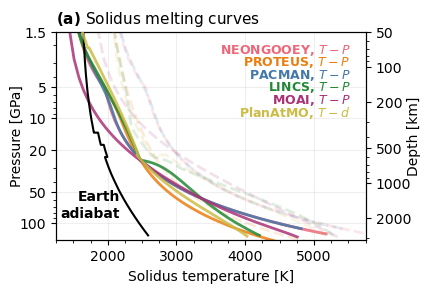

neongooey
proteus
pacman
lincs
moai
planatmo


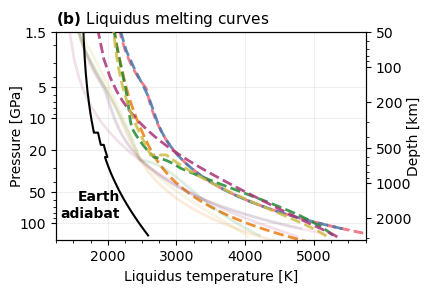

In [5]:

iplot = 0

def plot_melting_curve(curve, legend=True):

    global iplot

    fig,ax = plt.subplots(figsize=(4,2.7))

    xmin = 1250.0
    xmax = 2000.0

    axr = ax.twinx()

    p = earth_curve['p'] 
    t = earth_curve['t']
    d = earth_curve['d']
    # axr.plot(t, d, color='grey')
    ax.plot(t, p, color='k', zorder=15)
    idx = np.argmin(np.abs(p - 70))
    ax.text(t[idx]-100, p[idx], "Earth\nadiabat", zorder=16,
                ha='right', va='center', color='k', fontsize=10, weight='bold')
    
    cmb_p = np.amax(p)
    cmb_d = np.amax(d)

    pmin = np.amin(p)
    pmax = np.amax(p) * 1.1

    ax.set_yscale("log")
    ax.set_ylim(top=pmin, bottom=pmax)
    ax.set_yticks([pmin, 5, 10, 20, 50, 100])
    ax.set_ylabel("Pressure [GPa]", labelpad=-3)

    dmin = np.amin(d)
    dmax = np.amax(d) * 1.1

    axr.set_yscale("log")
    axr.set_ylim(top=dmin, bottom=dmax)
    axr.set_yticks([dmin,  100, 200, 500, 1000, 2000])
    axr.set_ylabel("Depth [km]", labelpad=-3)

    for axx in [ax, axr]:
        axx.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
        axx.yaxis.set_minor_locator(mpl.ticker.LogLocator(base = 10.0, subs = np.arange(1.0, 10.0) * 0.1, numticks = 999))

    hatch = {
        # "proteus": "////",
        # "pacman": "...."
    }

    im = -1
    for model in models:

        curves = melt_curves[model]
        if curves is None:
            continue
        print(model)
        im += 1

        col = get_color(model)
        lbl = get_label(model)
        
        # pressure or depth
        p = curves['p'] 
        d = curves['d']

        s = curves['tsol']
        l = curves['tliq']

        # solidus and liquidus
        if curve == "Solidus":
            la_s = 0.85
            la_l = 0.15
            title = r"$\mathbf{(a)}$ Solidus melting curves"
        elif curve == "Liquidus":
            la_s = 0.15
            la_l = 0.85
            title = r"$\mathbf{(b)}$ Liquidus melting curves"
        else:
            raise ValueError(f"Unknown curve: {curve}")


        # determine which independent variable to plot against
        if p is not None:
            y = p
            imax = np.argmin(np.abs(p - pmax))
            icmb = np.argmin(np.abs(p - cmb_p))
            axy = ax
            lbl += r", $T-P$"
        else:
            y = d
            imax = np.argmin(np.abs(d - dmax))
            icmb = np.argmin(np.abs(d - cmb_d))
            axy = axr
            lbl += r", $T-d$"

        if curve == "Solidus":
            print(f"     solidus  at CMB: {s[icmb]:.0f} K")
            print(f"     liquidus at CMB: {l[icmb]:.0f} K")

        # plot the curve
        lw = 2.0
        axy.plot(s, y,  ls='solid',  color=col, zorder=im, alpha=la_s, lw=lw)
        axy.plot(l, y,  ls='dashed', color=col, zorder=im, alpha=la_l, lw=lw)

        # fa = 0.01
        # ha = hatch.get(model, None)
        # axy.fill_betweenx(y, s, l, color=col, alpha=fa, linewidth=0, zorder=im, hatch=ha)


        # legend entry
        if legend:
            xtxt = 0.95
            ytxt = 0.95 - 0.06*im
            ax.text(xtxt, ytxt, lbl,  ha='right', va='top', 
                    transform=ax.transAxes,
                    zorder=30, color=col, fontsize=9, weight='bold')

        # update the x limits
        xmax = max(xmax, l[imax])

    ax.grid(alpha=0.2, zorder=0)
    ax.set_xlim(left=xmin, right=xmax)
    axr.set_xlim(left=xmin, right=xmax)

    ax.set_xlabel(f"{curve} temperature [K]")
    ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(1000))
    ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(250))

    ax.set_title(title, loc='left', color='k', fontsize=11)
    iplot += 1

    plt.show()
    fig.savefig(f"out/melting_curve_{curve}.{EXT}", bbox_inches='tight', dpi=DPI, pad_inches=0.03)

plot_melting_curve("Solidus")
plot_melting_curve("Liquidus", legend=False)